In [9]:
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt
import math 
from scipy.special import genlaguerre as genlag
from numpy.polynomial import Laguerre

%matplotlib notebook
%pylab

Using matplotlib backend: nbAgg
Populating the interactive namespace from numpy and matplotlib


In [10]:
aa=1.5
b=6
Nx=100
h_bar=1.9e5 #in KJ.A.mol-1.c-2
m=3.36e11# in kj.mol-1.c^-2 (is a reduced mas) (I multiplied by the inverse of the Avogadro constante A )

############################# CCSD(T) aug-cc-pVQZ########################################
a=2.12# in 1/A
De=9.37#in Kj/mol
re=1.9#in A

Lambda = np.sqrt((2*De*m))/(a*h_bar) # in (Kj/mol)^2
r=np.linspace(aa,b,Nx-1)

# ##############  Construct the Potential ###############
r=np.linspace(aa,b,Nx-1)
z=(r-re)
def V(z):
    #return De*(1-np.exp(-a*z))**2
    return De*(np.exp(-2*a*z)-2*np.exp(-a*z))

# ##############  Construct the Energies ###############

h=2*np.pi*h_bar
mu_o=(a/(2*np.pi))*np.sqrt((2*De)/m)

n=np.array([ 0,  1, 2,  3]) #Quantum number can go up to 3 in this case where (lamda - 0.5) =3.605
E=h*mu_o*(n+1/2)-((h*mu_o*(n+1/2))**2/(4*De)) 

# ##############  Construct the Generalized Laguerre Polynomial ###############
n0=0
n1=1
n2=2
n3=3

b0=2*Lambda-2*n0-1
b1=2*Lambda-2*n1-1
b2=2*Lambda-2*n2-1
b3=2*Lambda-2*n3-1

x=2*Lambda*np.exp(-a*z)################################### to modify in case ####################################

def L0(x):
    return 1

def L1(x):
    return -x + b1 + 1

def L2(x):
    return (1/2)*(x**2 - 2*(b2+2)*x + (b2+1)*(b2+2))

def L3(x):
    return (1/6)*((-x)**3 + 3*(b3+3)*(x**2) - 3*(b3+2)*(b3+3)*x + (b3+1)*(b3+2)*(b3+3))

# ##############  Construct the wave functions ###############
N_0=((math.factorial(0)*a*(2*Lambda-2*n0-1))/(math.gamma(2*Lambda-n0)))**(1/2)
N_1=((math.factorial(1)*a*(2*Lambda-2*n1-1))/(math.gamma(2*Lambda-n1)))**(1/2)
N_2=((math.factorial(2)*a*(2*Lambda-2*n2-1))/(math.gamma(2*Lambda-n2)))**(1/2)
N_3=((math.factorial(3)*a*(2*Lambda-2*n3-1))/(math.gamma(2*Lambda-n3)))**(1/2)
# N_3

Phi_0=N_0*x**(b0/2)*(np.exp((-1/2)*x))*L0(x)
Phi_1=N_1*x**(b1/2)*(np.exp((-1/2)*x))*L1(x)
Phi_2=N_2*x**(b2/2)*(np.exp((-1/2)*x))*L2(x)
Phi_3=N_3*x**(b3/2)*(np.exp((-1/2)*x))*L3(x)
# Phi_4=N_4*z**(Lambda-n4-(1/2))*(np.exp((-1/2)*z))*L4
Phi_0


array([5.20268337e-02, 1.14809373e-01, 2.23548658e-01, 3.88555885e-01,
       6.09250449e-01, 8.70059815e-01, 1.14150612e+00, 1.38675271e+00,
       1.57112365e+00, 1.67079720e+00, 1.67760542e+00, 1.59890511e+00,
       1.45352258e+00, 1.26587779e+00, 1.06037798e+00, 8.57425246e-01,
       6.71460980e-01, 5.10769098e-01, 3.78423805e-01, 2.73743850e-01,
       1.93769738e-01, 1.34486095e-01, 9.16878449e-02, 6.15047464e-02,
       4.06556376e-02, 2.65179799e-02, 1.70885384e-02, 1.08918508e-02,
       6.87342156e-03, 4.29853073e-03, 2.66628676e-03, 1.64158617e-03,
       1.00389925e-03, 6.10180066e-04, 3.68819558e-04, 2.21810266e-04,
       1.32789609e-04, 7.91672283e-05, 4.70210970e-05, 2.78328457e-05,
       1.64239463e-05, 9.66445183e-06, 5.67244019e-06, 3.32168388e-06,
       1.94104457e-06, 1.13210333e-06, 6.59153651e-07, 3.83183547e-07,
       2.22438397e-07, 1.28959289e-07, 7.46770958e-08, 4.31977630e-08,
       2.49641567e-08, 1.44142861e-08, 8.31620459e-09, 4.79451751e-09,
      

<IPython.core.display.Javascript object>


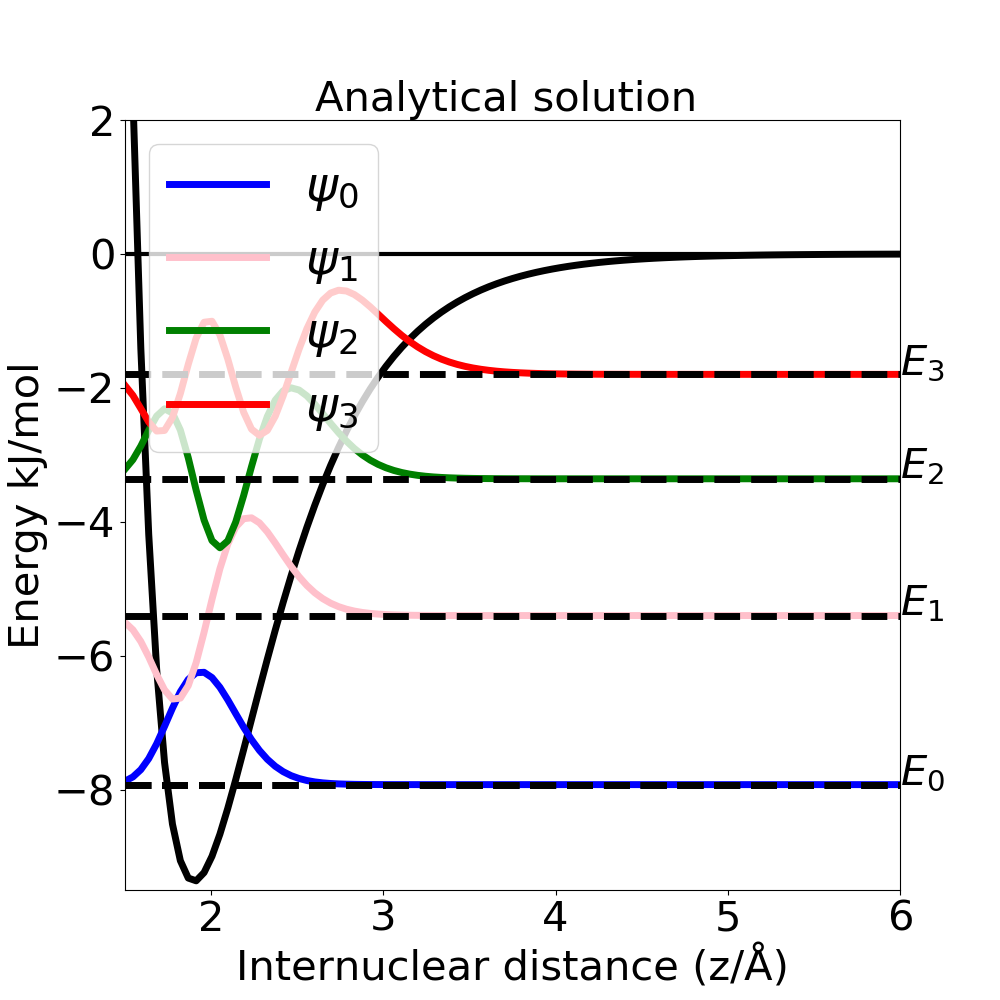

In [11]:
# ##############  Plot all together ###############
fig, ax = plt.subplots(figsize=(10,10))
# rr=np.linspace(aa,b,Nx-2) # you will end at 97
ax.plot(r,V(z), color='black', lw=5)
plt.axhline(y=0,  color ='black',lw=3)
#rrr=np.linspace(aa,aa+1.5,Nx-1)

#plt.axhline(E[n]-De, color='black', linestyle='--', label= "$E_{n}$",lw=5)
plt.plot(r,(Phi_0)+(E[0]-De),color='b',label= '$\psi_{0}$',lw=5)
plt.plot(r,(Phi_1)+(E[1]-De), 'pink', label= '$\psi_{1}$', lw=5)
plt.plot(r,(Phi_2)+(E[2]-De), 'g',label= '$\psi_{2}$',lw=5)
plt.plot(r,Phi_3+E[3]-De, 'red',label= '$\psi_{3}$',lw=5)
for n in range(4):
#     plt.plot(r,Phi_3+E[3], lw=2)
    plt.axhline(E[n]-De, color='black', linestyle='--',lw=5)
    plt.axhline(E[0]-De, color='black', linestyle='--',lw=5)
    #plt.axhline([0], color='black', linestyle='--')
    plt.text(6, E[n]-De, f"$E_{n}$",fontsize=30)

# # plt.axhline(Phi_n, color='red', linestyle='-')
plt.tick_params(labelsize=30)
plt.xlabel('Internuclear distance (z/Å)', fontsize=30)
plt.ylabel('Energy kJ/mol',fontsize=30)
plt.title('Analytical solution ',fontsize=30)
plt.xlim(1.5, 6)
plt.ylim(-9.5, 2)
#plt.legend()
plt.legend(loc = 3)
plt.legend(prop={'size':35})
plt.show()


In [13]:
print('-----------------Table of Values (States Index VS Energies)-------------')
print("{:8d} {:24.4f} ".format(0,E[0]-De))
print("{:8d} {:24.4f} ".format(1,E[1]-De))
print("{:8d} {:24.4f} ".format(2,E[2]-De))
print("{:8d} {:24.3f} ".format(3,E[3]-De))


-----------------Table of Values (States Index VS Energies)-------------
       0                  -7.9263 
       1                  -5.4010 
       2                  -3.3585 
       3                   -1.799 
